<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# TP2 - Detección de máximo enfoque mediante análisis espectral

**Materia:** Visión por Computadora I

**Profesor:** Ing. Maxim Dorogov

**Alumnos:** <br>
Juan Sebastián Bonals - jsbonals@gmail.com  <br>
Federico Santiago Fontanari - federicofontanari@gmail.com  <br>
Jose Andres Montes de Oca - amontesdeoca1982@gmail.com  <br>

**Objetivo:** implementar un detector de máximo enfoque sobre un video, aplicando una técnica de análisis espectral similar a la que usan las cámaras digitales modernas para autofocus. Se implementa la métrica de nitidez propuesta en el paper *"Image Sharpness Measure for Blurred Images in Frequency Domain"* y se aplica sobre `focus_video.mov`.

In [14]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
REPO_URL = 'https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/vision_computadora_I.git'
REPO_DIR = 'vision_computadora_I'

if not os.path.exists(REPO_DIR):
    !git clone -q {REPO_URL}

if not os.path.exists('focus_video.mov'):
    os.symlink(f'{REPO_DIR}/Material_TPs/TP2/focus_video.mov', 'focus_video.mov')

VIDEO_PATH = 'focus_video.mov'

In [16]:
from moviepy.editor import VideoFileClip

# Carga tu archivo de video
clip_original = VideoFileClip(VIDEO_PATH)
clip_original.ipython_display(autoplay=True, loop=True)

Moviepy - Building video __temp__.mp4.
MoviePy - Writing audio in __temp__TEMP_MPY_wvf_snd.mp3


MoviePy - Done.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


## Métrica de nitidez

El algoritmo del paper es el siguiente, para una imagen $I$ de tamaño $M \times N$:

1. Calcular $F$, la Transformada de Fourier de $I$.
2. Calcular $F_c$, centrando el espectro (`fftshift`).
3. Calcular $AF = |F_c|$, el módulo del espectro centrado.
4. Calcular $M_{max} = \max(AF)$.
5. Calcular $Th$ = cantidad de píxeles de $AF$ cuyo valor supera el umbral $\textit{thres} = M_{max}/1000$.
6. La medida de nitidez es $FM = \dfrac{Th}{M \cdot N}$.

La idea detrás de esto es simple: una imagen nítida tiene mucha energía en altas frecuencias (bordes, detalle fino), mientras que una imagen desenfocada concentra casi toda su energía en las bajas frecuencias (cerca del centro del espectro). Contar cuántos píxeles del espectro superan un umbral relativo al máximo es una forma barata de cuantificar "cuánta" alta frecuencia sobrevive.

In [4]:
def medir_nitidez(gray):
    # Metrica FM de De & Masilamani (2013): "Image Sharpness Measure for Blurred Images in Frequency Domain"
    F = np.fft.fft2(gray.astype(np.float64))
    Fc = np.fft.fftshift(F)
    AF = np.abs(Fc)
    M_max = np.max(AF)
    thres = M_max / 1000.0
    Th = np.sum(AF > thres)
    h, w = gray.shape
    FM = Th / (h * w)
    return FM

In [5]:
def leer_frames(path):
    cap = cv.VideoCapture(path)
    if not cap.isOpened():
        raise IOError(f'No se pudo abrir el video: {path}')
    fps = cap.get(cv.CAP_PROP_FPS)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()
    return frames, fps

frames, fps = leer_frames(VIDEO_PATH)
H, W = frames[0].shape[:2]
print(f'Frames leidos: {len(frames)} | Resolucion: {W}x{H} | FPS: {fps:.2f}')

Frames leidos: 171 | Resolucion: 640x360 | FPS: 29.97


## Experimento 1: métrica sobre el frame completo

Frame de maximo enfoque (frame completo): 109 (FM = 0.02862)


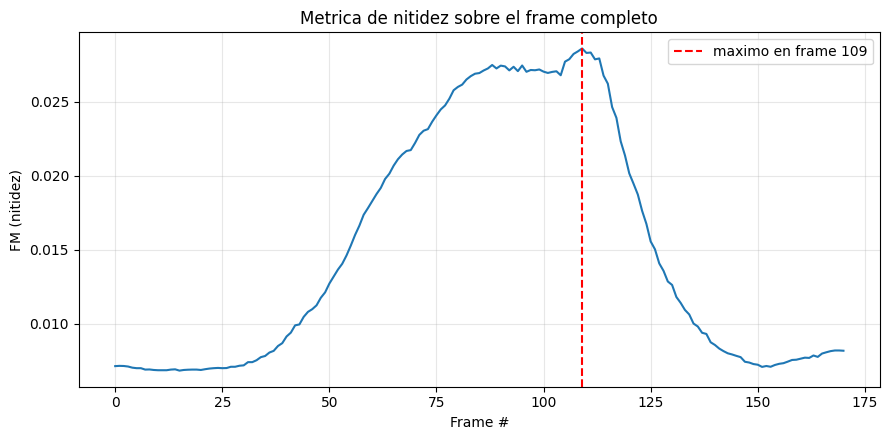

In [6]:
fm_full = np.array([
    medir_nitidez(cv.cvtColor(f, cv.COLOR_BGR2GRAY))
    for f in frames
])

frame_max_full = int(np.argmax(fm_full))
print(f'Frame de maximo enfoque (frame completo): {frame_max_full} (FM = {fm_full[frame_max_full]:.5f})')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(fm_full)
ax.axvline(frame_max_full, color='r', linestyle='--', label=f'maximo en frame {frame_max_full}')
ax.set_xlabel('Frame #'); ax.set_ylabel('FM (nitidez)')
ax.set_title('Metrica de nitidez sobre el frame completo')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Experimento 2: métrica sobre una ROI central (10% del área total)

Definimos un ROI cuadrado centrado en el frame, cuya área sea el 10% del área total del cuadro.

ROI: 151x151 px  (~9.90% del area total del frame)
Frame de maximo enfoque (ROI central): 111 (FM = 0.34740)


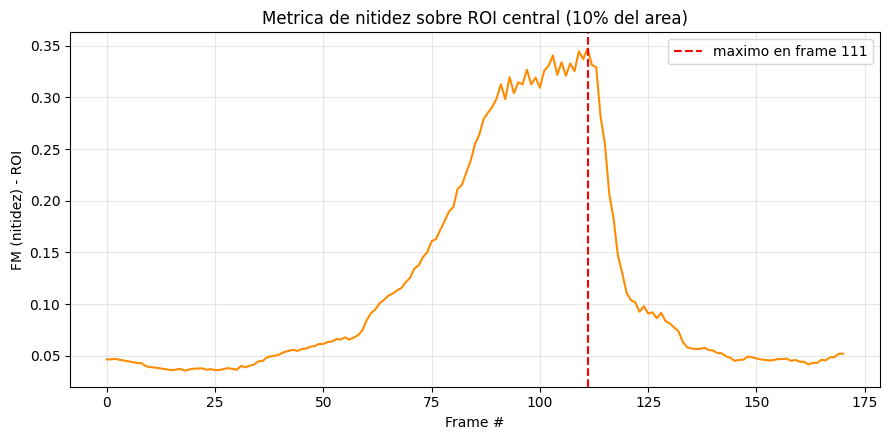

In [7]:
pct_roi = 0.10
lado = int(np.sqrt(pct_roi * H * W))
x0 = W // 2 - lado // 2
y0 = H // 2 - lado // 2

area_pct_real = 100 * (lado * lado) / (H * W)
print(f'ROI: {lado}x{lado} px  (~{area_pct_real:.2f}% del area total del frame)')

fm_roi = np.array([
    medir_nitidez(cv.cvtColor(f, cv.COLOR_BGR2GRAY)[y0:y0+lado, x0:x0+lado])
    for f in frames
])

frame_max_roi = int(np.argmax(fm_roi))
print(f'Frame de maximo enfoque (ROI central): {frame_max_roi} (FM = {fm_roi[frame_max_roi]:.5f})')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(fm_roi, color='darkorange')
ax.axvline(frame_max_roi, color='r', linestyle='--', label=f'maximo en frame {frame_max_roi}')
ax.set_xlabel('Frame #'); ax.set_ylabel('FM (nitidez) - ROI')
ax.set_title(f'Metrica de nitidez sobre ROI central ({area_pct_real:.0f}% del area)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

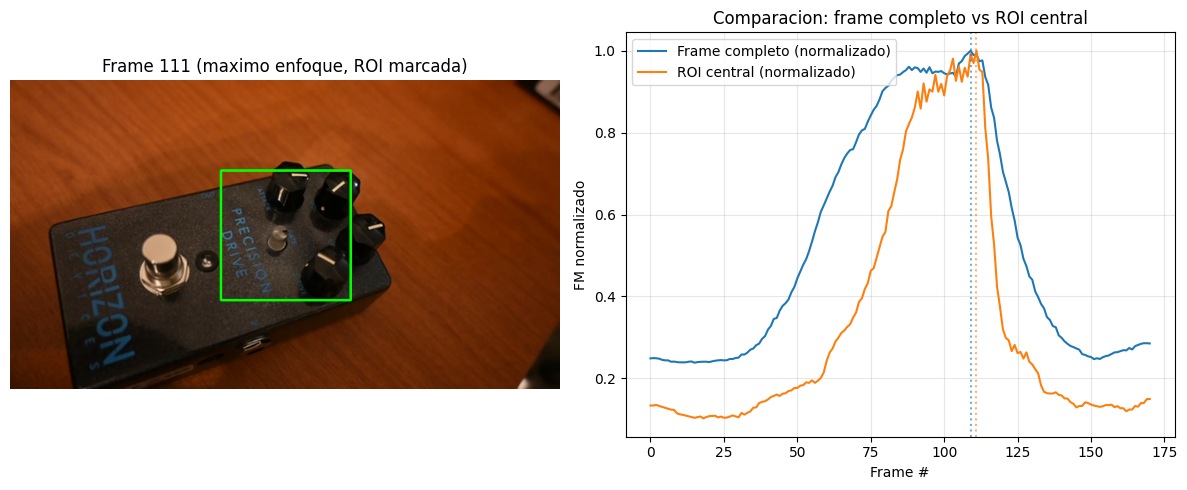

In [8]:
frame_dibujo = frames[frame_max_roi].copy()
cv.rectangle(frame_dibujo, (x0, y0), (x0+lado, y0+lado), (0, 255, 0), 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv.cvtColor(frame_dibujo, cv.COLOR_BGR2RGB))
axes[0].set_title(f'Frame {frame_max_roi} (maximo enfoque, ROI marcada)')
axes[0].axis('off')

axes[1].plot(fm_full / fm_full.max(), label='Frame completo (normalizado)')
axes[1].plot(fm_roi / fm_roi.max(), label='ROI central (normalizado)')
axes[1].axvline(frame_max_full, color='C0', linestyle=':', alpha=0.6)
axes[1].axvline(frame_max_roi, color='C1', linestyle=':', alpha=0.6)
axes[1].set_xlabel('Frame #'); axes[1].set_ylabel('FM normalizado')
axes[1].set_title('Comparacion: frame completo vs ROI central')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

Ambas curvas (frame completo y ROI central) muestran la misma forma de campana, con el pico de enfoque ubicado en la misma zona del video (entre los frames ~90 y ~115), lo cual es consistente y esperable ya que el objeto de interés (el pedal de guitarra) está centrado en el cuadro.

La diferencia importante está en la magnitud relativa de la métrica: sobre la ROI central, los valores de FM son notoriamente más altos (~0.35 en el pico vs ~0.028 sobre el frame completo). Esto tiene sentido ya que al restringir la métrica a la zona donde efectivamente está el objeto en foco, se elimina el "ruido" que aporta el fondo. Este ruido siempre está parcialmente desenfocado por la profundidad de campo. Por ende, la métrica queda más contrastada entre frames en foco y frames desenfocados. En otras palabras, medir sobre una ROI central hace que el detector de foco sea más sensible o discriminativo que medir sobre todo el cuadro.

## Puntos extra: Unsharp Masking para expandir la zona de enfoque

La idea es aplicar *unsharp masking* (realce de bordes) sobre los frames del video y ver si esto permite que más frames "crucen" el umbral de calidad que originalmente solo alcanzaban los frames realmente nítidos, expandiendo así la zona percibida como "en foco".

In [9]:
def unsharp_mask(img_bgr, sigma=3.0, monto=2.0):
    blur = cv.GaussianBlur(img_bgr, (0, 0), sigma)
    return cv.addWeighted(img_bgr, 1 + monto, blur, -monto, 0)

frames_unsharp = [unsharp_mask(f) for f in frames]
fm_unsharp = np.array([
    medir_nitidez(cv.cvtColor(f, cv.COLOR_BGR2GRAY))
    for f in frames_unsharp
])

print(f'FM maximo original:  {fm_full.max():.5f}')
print(f'FM maximo unsharp:   {fm_unsharp.max():.5f}')

FM maximo original:  0.02862
FM maximo unsharp:   0.08436


Umbral fijo (90% del maximo original): 0.02576
Zona en foco - ORIGINAL:  frames 79-115  (37 frames)
Zona en foco - UNSHARP:   frames 55-126  (72 frames)
Expansion: 35 frames adicionales considerados "en foco"


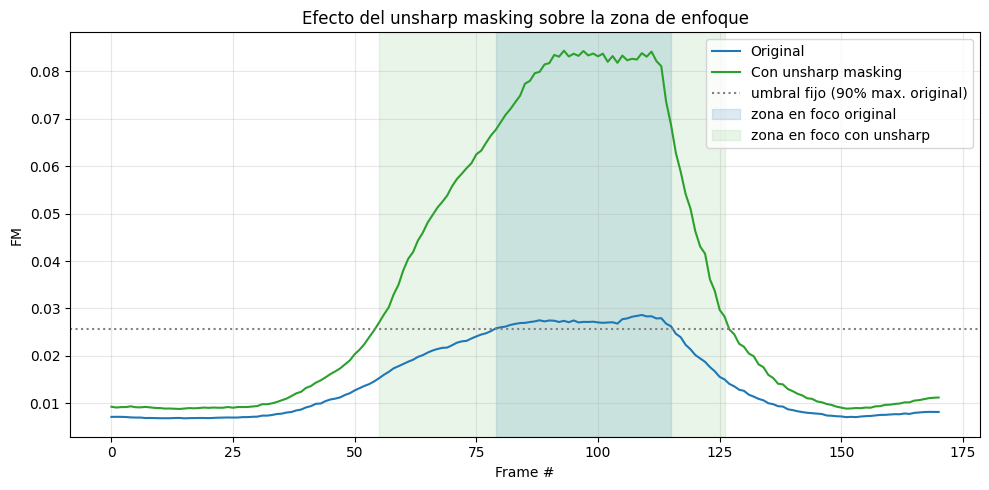

In [10]:
# Definimos la "zona de enfoque" como los frames cuyo FM supera un umbral FIJO,
# calculado a partir del video ORIGINAL (90% de su maximo). Comparamos cuantos
# frames superan ese mismo umbral antes y despues de aplicar unsharp masking.
umbral_fijo = fm_full.max() * 0.90

zona_orig = np.where(fm_full >= umbral_fijo)[0]
zona_unsharp = np.where(fm_unsharp >= umbral_fijo)[0]

print(f'Umbral fijo (90% del maximo original): {umbral_fijo:.5f}')
print(f'Zona en foco - ORIGINAL:  frames {zona_orig.min()}-{zona_orig.max()}  ({len(zona_orig)} frames)')
print(f'Zona en foco - UNSHARP:   frames {zona_unsharp.min()}-{zona_unsharp.max()}  ({len(zona_unsharp)} frames)')
print(f'Expansion: {len(zona_unsharp) - len(zona_orig)} frames adicionales considerados "en foco"')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fm_full, label='Original', color='C0')
ax.plot(fm_unsharp, label='Con unsharp masking', color='C2')
ax.axhline(umbral_fijo, color='gray', linestyle=':', label='umbral fijo (90% max. original)')
ax.axvspan(zona_orig.min(), zona_orig.max(), color='C0', alpha=0.15, label='zona en foco original')
ax.axvspan(zona_unsharp.min(), zona_unsharp.max(), color='C2', alpha=0.10, label='zona en foco con unsharp')
ax.set_xlabel('Frame #'); ax.set_ylabel('FM')
ax.set_title('Efecto del unsharp masking sobre la zona de enfoque')
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Importante:** si comparamos ambas curvas usando cada una su propio máximo (umbral relativo recalculado sobre cada video), el unsharp masking en realidad angosta la zona relativa de enfoque, porque amplifica más a los frames que ya tenían bastante alta frecuencia (los nítidos) que a los frames muy desenfocados (que casi no tienen alta frecuencia para amplificar). Por eso la comparación correcta para mostrar la "expansión" es usar un umbral fijo, definido a partir de la calidad del video original: ahí sí se ve claramente que el unsharp masking permite que frames que antes no llegaban a ese nivel de nitidez ahora sí lo alcancen, expandiendo la ventana de frames utilizables.

In [11]:
# Guardamos el video procesado con unsharp masking
OUTPUT_VIDEO_PATH = 'focus_video_unsharp.mp4'
fourcc = cv.VideoWriter_fourcc(*'mp4v')
writer = cv.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps, (W, H))
for f in frames_unsharp:
    writer.write(f)
writer.release()
print(f'Video procesado guardado en: {OUTPUT_VIDEO_PATH}')

Video procesado guardado en: focus_video_unsharp.mp4


In [17]:
# Carga tu archivo de video
clip_unsharp = VideoFileClip("focus_video_unsharp.mp4")
clip_unsharp.ipython_display(autoplay=True, loop=True)

Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


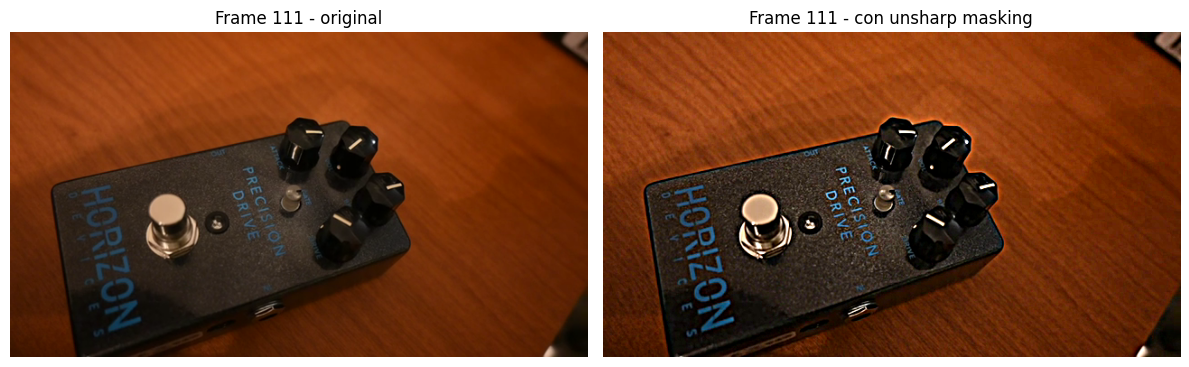

In [13]:
# Comparacion visual de un frame antes/despues del unsharp masking
idx_ejemplo = frame_max_roi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv.cvtColor(frames[idx_ejemplo], cv.COLOR_BGR2RGB))
axes[0].set_title(f'Frame {idx_ejemplo} - original'); axes[0].axis('off')
axes[1].imshow(cv.cvtColor(frames_unsharp[idx_ejemplo], cv.COLOR_BGR2RGB))
axes[1].set_title(f'Frame {idx_ejemplo} - con unsharp masking'); axes[1].axis('off')
plt.tight_layout()
plt.show()

## Conclusiones

- La métrica de nitidez en el dominio de la frecuencia propuesta permite detectar automáticamente, sin supervisión, en qué frames del video el objeto está en foco.
- Medir sobre una ROI central en lugar del frame completo aumenta el contraste de la métrica entre frames en foco y desenfocados, siendo más sensible al objeto de interés.
- El unsharp masking puede usarse para "recuperar" nitidez aparente en frames moderadamente desenfocados, expandiendo la ventana de frames aceptables según un criterio de calidad fijo. Aunque no reconstruye información de alta frecuencia genuinamente perdida, solo amplifica lo que queda.